In [4]:
#find path
import os

for root, dirs, files in os.walk("/"):
    if "final_clean_dataset.csv" in files:
        print(os.path.join(root, "final_clean_dataset.csv"))
        break

/System/Volumes/Data/Users/megan/Desktop/545 Project/chest-xrays-indiana-university/final_clean_dataset.csv


In [5]:
import os
import glob
import pandas as pd

# paths
csv_path = "/System/Volumes/Data/Users/megan/Desktop/545 Project/chest-xrays-indiana-university/final_clean_dataset.csv"
image_dir = "/System/Volumes/Data/Users/megan/Desktop/545 Project/chest-xrays-indiana-university/images/valid_uid_images/front"

# read csv
df = pd.read_csv(csv_path)

# read col
print(df.columns.tolist())
print(df.head())

# uid -> image path 
uid_to_path = {}

image_files = glob.glob(os.path.join(image_dir, "*.png"))

for img_path in image_files:
    fname = os.path.basename(img_path)
    
    
    # uid using "_"
    uid_str = fname.split("_")[0]
    
    try:
        uid = int(uid_str)
        uid_to_path[uid] = img_path
    except ValueError:
        print(f"Skip invalid filename: {fname}")

# map to dataframe
df["path"] = df["uid"].map(uid_to_path)

# check if there is missing rows
print("Total rows:", len(df))
print("Matched rows:", df["path"].notna().sum())
print("Missing rows:", df["path"].isna().sum())

# see which uid didn't match
missing_df = df[df["path"].isna()]
print(missing_df[["uid"]].head(20))

# preserve those with mapping
df = df.dropna(subset=["path"]).reset_index(drop=True)

print("\nAfter dropping missing paths:")
print(df[["uid", "normal", "path"]].head())

['uid', 'abdomen', 'adipose tissue', 'airspace disease', 'aorta', 'aorta thoracic', 'aortic aneurysm', 'arthritis', 'atherosclerosis', 'blister', 'blood vessels', 'bone and bones', 'bone diseases metabolic', 'breast implants', 'bronchiectasis', 'bronchiolitis', 'bronchitis', 'bullous emphysema', 'calcified granuloma', 'calcinosis', 'cardiac shadow', 'cardiomegaly', 'catheters indwelling', 'cavitation', 'cervical vertebrae', 'cholelithiasis', 'cicatrix', 'colonic interposition', 'consolidation', 'contrast media', 'costophrenic angle', 'cystic fibrosis', 'cysts', 'deformity', 'density', 'diaphragm', 'diaphragmatic eventration', 'dislocations', 'emphysema', 'epicardial fat', 'expansile bone lesions', 'fibrosis', 'foreign bodies', 'fractures bone', 'funnel chest', 'granuloma', 'granulomatous disease', 'heart', 'heart atria', 'heart failure', 'heart ventricles', 'hemopneumothorax', 'hemothorax', 'hernia diaphragmatic', 'hernia hiatal', 'humerus', 'hydropneumothorax', 'hyperostosis diffuse i

In [6]:
df = df.dropna(subset=["path"]).reset_index(drop=True)
df["label"] = (df["normal"] == 0).astype(int)

df.to_csv("matched_frontal_dataset.csv", index=False)
print(df[["uid", "normal", "label", "path"]].head())

   uid  normal  label                                               path
0    1       1      0  /System/Volumes/Data/Users/megan/Desktop/545 P...
1    2       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
2    3       1      0  /System/Volumes/Data/Users/megan/Desktop/545 P...
3    4       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
4    5       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("matched_frontal_dataset.csv")

normal_df = df[df["normal"] == 1].copy()
abnormal_df = df[df["normal"] == 0].copy()

# normal -> train / val / test
train_normal, temp_normal = train_test_split(
    normal_df, test_size=0.3, random_state=42, shuffle=True
)

val_normal, test_normal = train_test_split(
    temp_normal, test_size=2/3, random_state=42, shuffle=True
)

# abnormal -> val / test only
val_abnormal, test_abnormal = train_test_split(
    abnormal_df, test_size=0.7, random_state=42, shuffle=True
)

train_df = train_normal.copy()
val_df = pd.concat([val_normal, val_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([test_normal, test_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train label counts:")
print(train_df["label"].value_counts())

print("\nVal label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

train_df.to_csv("train_padim.csv", index=False)
val_df.to_csv("val_padim.csv", index=False)
test_df.to_csv("test_padim.csv", index=False)

Train label counts:
label
0    809
Name: count, dtype: int64

Val label counts:
label
1    597
0    116
Name: count, dtype: int64

Test label counts:
label
1    1393
0     232
Name: count, dtype: int64


Image size: (2496, 2048)


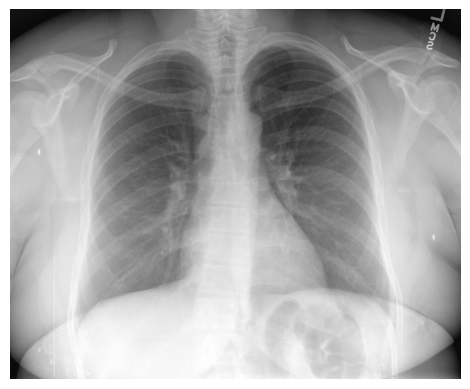

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

train_df = pd.read_csv("train_padim.csv")

img_path = train_df.iloc[0]["path"]
img = Image.open(img_path).convert("RGB")

print("Image size:", img.size)
plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
print(train_df["normal"].value_counts())
print(val_df["normal"].value_counts())
print(test_df["normal"].value_counts())

normal
1    809
Name: count, dtype: int64
normal
0    597
1    116
Name: count, dtype: int64
normal
0    1393
1     232
Name: count, dtype: int64


In [10]:
abnormal_samples = test_df[test_df["label"] == 1].head(5)
print(abnormal_samples[["uid", "normal", "label", "path"]])

    uid  normal  label                                               path
1  3878       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
2   600       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
3  1921       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
4  3149       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
5  2036       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...


In [11]:
import pandas as pd

# make sure uid is integer
df["uid"] = pd.to_numeric(df["uid"], errors="coerce")
df = df.dropna(subset=["uid"]).copy()
df["uid"] = df["uid"].astype(int)

# binary label
# normal=1 -> label=0
# normal=0 -> label=1
df["label"] = (df["normal"] == 0).astype(int)

# drop no matching
df = df.dropna(subset=["path"]).reset_index(drop=True)

# save matched data
df.to_csv("matched_frontal_dataset.csv", index=False)

print("Saved: matched_frontal_dataset.csv")
print(df[["uid", "normal", "label", "path"]].head())
print("Total matched rows:", len(df))

Saved: matched_frontal_dataset.csv
   uid  normal  label                                               path
0    1       1      0  /System/Volumes/Data/Users/megan/Desktop/545 P...
1    2       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
2    3       1      0  /System/Volumes/Data/Users/megan/Desktop/545 P...
3    4       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
4    5       0      1  /System/Volumes/Data/Users/megan/Desktop/545 P...
Total matched rows: 3147


In [12]:
from sklearn.model_selection import train_test_split

#  normal / abnormal
normal_df = df[df["normal"] == 1].copy()
abnormal_df = df[df["normal"] == 0].copy()

# normal -> train / val / test
train_normal, temp_normal = train_test_split(
    normal_df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_normal, test_normal = train_test_split(
    temp_normal,
    test_size=2/3,
    random_state=42,
    shuffle=True
)

# abnormal -> val / test only
val_abnormal, test_abnormal = train_test_split(
    abnormal_df,
    test_size=0.7,
    random_state=42,
    shuffle=True
)

# combine 
train_df = train_normal.copy()
val_df = pd.concat([val_normal, val_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([test_normal, test_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# save data
train_df.to_csv("train_padim.csv", index=False)
val_df.to_csv("val_padim.csv", index=False)
test_df.to_csv("test_padim.csv", index=False)

print("Saved: train_padim.csv, val_padim.csv, test_padim.csv")

Saved: train_padim.csv, val_padim.csv, test_padim.csv


In [13]:
# check data
import os

for f in [
    "matched_frontal_dataset.csv",
    "train_padim.csv",
    "val_padim.csv",
    "test_padim.csv"
]:
    print(f, "exists:", os.path.exists(f))

matched_frontal_dataset.csv exists: True
train_padim.csv exists: True
val_padim.csv exists: True
test_padim.csv exists: True


In [14]:
print("Train label counts:")
print(train_df["label"].value_counts())

print("\nVal label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train label counts:
label
0    809
Name: count, dtype: int64

Val label counts:
label
1    597
0    116
Name: count, dtype: int64

Test label counts:
label
1    1393
0     232
Name: count, dtype: int64
